## CA 4 - Large Language Models (Spring 2026)

- **Name: Ali Rajabzadeh**
- **Student ID: 810104137**

---
### Retrieval-Augmented Question Answering with Small Language Models

This notebook contains the step-by-step implementation of a **Retrieval-Augmented Generation (RAG)** pipeline for answering document-grounded multiple-choice questions. The goal is to evaluate whether retrieval can improve the performance of a small language model on questions generated from course-related PDF documents.

In this assignment, you will load and preprocess PDF files, split them into chunks, build both **sparse** and **dense** retrievers, and compare three question-answering pipelines:

1. A vanilla small language model without retrieval.
2. A RAG pipeline using a BM25 sparse retriever.
3. A RAG pipeline using a FAISS dense retriever.

Finally, you will evaluate the pipelines on a multiple-choice benchmark and compare their accuracy across different question difficulty levels.

In [1]:
# Install the required packages

!pip install -q huggingface_hub langchain langchain-community pypdf 
!pip install -q sentence-transformers lancedb pyarrow tantivy langchain-text-splitters
!pip install -q faiss-cpu langchain-huggingface rank-bm25
!pip install -q transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.3/554.3 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-co

In [2]:
!ls /kaggle/input/datasets/alirajabzadehchenari/speech-and-language-processing

10.pdf	11.pdf	13.pdf	benchmark_set.json  small_test_set.json


In [3]:
# the path to the pdfs 
from pathlib import Path
from typing import List


PDF_PATHS = [
    "/kaggle/input/datasets/alirajabzadehchenari/speech-and-language-processing/10.pdf",
    "/kaggle/input/datasets/alirajabzadehchenari/speech-and-language-processing/11.pdf",
    "/kaggle/input/datasets/alirajabzadehchenari/speech-and-language-processing/13.pdf",
]

# PDF_PATHS = [
#     "data/10.pdf",
#     "data/11.pdf",
#     "data/13.pdf",
# ]

PDF_PATHS = [Path(p) for p in PDF_PATHS]

### Loading and preprocessing PDF documents (5 Points)

In this step, you must prepare the raw PDF documents for retrieval.

Your tasks are:

- Load each PDF file in `PDF_PATHS` using LangChain's `PyPDFLoader`.
- Convert each PDF into page-level LangChain `Document` objects.
- Remove the last two pages of each PDF because they mostly contain references or bibliography content.
- Add the source PDF filename to the metadata of every remaining page using the key `"source_file"`.
- Store all processed pages from all PDFs in the list `docs`.

At the end of this cell, `docs` should contain all usable page-level documents that will later be split into smaller chunks.

In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document

docs = []

for pdf_path in PDF_PATHS:
    loader = PyPDFLoader(str(pdf_path))
    pages = loader.load()

    pages = pages[:-2] if len(pages) > 2 else []

    processed_pages = []
    for page in pages:
        new_metadata = dict(page.metadata)
        new_metadata["source_file"] = pdf_path.name

        processed_pages.append(
            Document(
                page_content=page.page_content,
                metadata=new_metadata
            )
        )

    docs.extend(processed_pages)

print("Loaded pages after removing last two pages:", len(docs))

/tmp/ipykernel_58/3650169529.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Loaded pages after removing last two pages: 66


### Splitting documents into chunks (5 Points)

In this step, you must split the page-level documents into smaller text chunks.

Your tasks are:

- Create a `RecursiveCharacterTextSplitter`.
- Set an appropriate `chunk_size` so each chunk contains enough context for answering questions.
- Set a `chunk_overlap` so neighboring chunks share some text and important information is less likely to be cut off.
- Apply the text splitter to the loaded documents in `docs`.
- Store the resulting chunks in the variable `chunks`.

These chunks will be used as the searchable units for both sparse and dense retrieval.

**Question:**  
Why do we split long documents into smaller chunks before building a retrieval system?

**Answer:**  
Model's context window is limited! So long documents may exceed the window. Therefore, we prefer to split the documents into smaller chunks. This makes focused units for retrieval. Not only does it improve precision, but it also reduces irrelevant information! It also helps retrieve only the most relevant passages for answering a question.

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)

chunks = text_splitter.split_documents(docs)

print("Number of chunks:", len(chunks))

Number of chunks: 295


### Building sparse and dense retrievers (5 Points)

In this step, you must build two different retrievers over the document chunks.

Your tasks are:

- Build a **dense retriever** using sentence embeddings and FAISS.
- Use the embedding model `"sentence-transformers/all-MiniLM-L6-v2"` to convert chunks into vectors.
- Store the vector index using `FAISS.from_documents`.
- Convert the FAISS vector store into a retriever with `k = 5`.
- Build a **sparse retriever** using BM25.
- Use the same document chunks for BM25 retrieval.
- Set `k = 5` so both retrievers return the top 5 most relevant chunks.

**Question:**  
What is the main difference between sparse retrieval such as BM25 and dense retrieval using embeddings?

**Answer:** 
Sparse retrieval such as BM25 is based on exact lexical matching (between query terms and document words) (We know that it uses term frequency and inverse document frequency)! When the query and the relevant document have some clear keywords in common, it works very well. On the other hand, dense retrieval uses neural embeddings for representing both queries and documents (in a continuous vector space). So we can say that it retrieves results based on semantic similarity! So it is more robust to variations in vocabulary. Therefore it can handle situations like paraphrasing!

In [6]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Create dense FAISS retriever
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(
    chunks,
    embedding_model
)

dense_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

print("Dense retriever is ready.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dense retriever is ready.


In [7]:
from langchain_community.retrievers import BM25Retriever

# Create BM25 sparse retriever
bm25_retriever = BM25Retriever.from_documents(chunks)

# Set number of retrieved documents to 5
bm25_retriever.k = 5

print("BM25 retriever is ready.")

BM25 retriever is ready.


In [8]:
# Test both retrievers

query = "What is self attention?"

dense_results = dense_retriever.invoke(query)
bm25_results = bm25_retriever.invoke(query)

print("Dense results:")
for doc in dense_results:
    # print(doc.metadata)
    print(doc.page_content)
    print("-" * 80)

print("BM25 results:")
for doc in bm25_results:
    # print(doc.metadata)
    print(doc.page_content)
    print("-" * 80)

Dense results:
since we are predicting something in the middle of our text rather than at the end.
We’ll discuss the ﬁrst here and the second in the following section.
Fig. 10.1a, reproduced here from Chapter 8, shows the information ﬂow in the
left-to-right approach of Chapter 8. The attention computation at each token is based
on the preceding (and current) input tokens, ignoring potentially useful information
located to the right of the token under consideration. Bidirectional encoders over-
come this limitation by allowing the attention mechanism to range over the entire
input, as shown in Fig. 10.1b.
a) A causal self-attention layer b) A bidirectional self-attention layer
attentionattentionattentionattentionattention
a1 a2 a3 a4 a5
x3 x4 x5x1 x2
attentionattentionattentionattentionattention
--------------------------------------------------------------------------------
attentionattentionattentionattentionattention
a1 a2 a3 a4 a5
x3 x4 x5x1 x2
attentionattentionattentionattentiona

### Loading the language model (5 points)

In this step, you must load the language model that will answer the multiple-choice questions.

Your tasks are:

- Load `"Qwen/Qwen2.5-0.5B-Instruct"` and its tokenizer.
- Wrap the Hugging Face pipeline with LangChain's `HuggingFacePipeline`.

We use a small instruction-tuned model because the goal of this assignment is to test whether retrieval can improve the performance of a lightweight language model.

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from langchain_community.llms import HuggingFacePipeline

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

# Create HF pipeline
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    do_sample=False,
    temperature=0.0,
    return_full_text=False
)

# Wrap in LangChain LLM
llm = HuggingFacePipeline(pipeline=pipe)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
/tmp/ipykernel_58/3875582889.py:30: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


In [10]:
import re
import torch
import pandas as pd
from tqdm.auto import tqdm
from typing import Dict, Any

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    AIMessagePromptTemplate,
)
from langchain_core.output_parsers import BaseOutputParser
from langchain_core.runnables import RunnableLambda

In [11]:
# loading test dataset
import json

with open("/kaggle/input/datasets/alirajabzadehchenari/speech-and-language-processing/small_test_set.json", "r", encoding="utf-8") as f:
    small_questions = json.load(f)

with open("/kaggle/input/datasets/alirajabzadehchenari/speech-and-language-processing/benchmark_set.json", "r", encoding="utf-8") as f:
    benchmark_questions = json.load(f)


print("Small set size:", len(small_questions))
print("Benchmark set size:", len(benchmark_questions))

Small set size: 5
Benchmark set size: 50


### Creating the vanilla question-answering pipeline (20 points)

In this step, you must build the first question-answering pipeline: a **vanilla LLM pipeline** without retrieval.

Your tasks are:

- Define a Pydantic schema for the model output.
- The output must contain:
  - `answer`: one of `"A"`, `"B"`, `"C"`, or `"D"`.
  - `reason`: a short explanation for the selected answer.
    Example output:
    ```python
    {"answer": "B", "reason": "The context describes this method as using lexical overlap."}
    ```
- The pipeline input should be a dictionary with one key:
```python
{"question": "full multiple-choice question here"}
```
This means the `HumanMessagePromptTemplate` must contain the variable `{question}`.  
For example, the human prompt should be defined so that it receives the question text from the `"question"` field of the input dictionary.

- Create a JSON output parser using the schema.
- Build a prompt using LangChain message prompt templates.
- The prompt should ask the model to answer multiple-choice questions and return structured JSON.
- Create a LangChain pipeline that:
  - formats the prompt,
  - sends it to the language model,
  - parses the JSON output.

In this pipeline, you will use three types of prompt templates:

- `SystemMessagePromptTemplate`: defines the general behavior of the model, such as answering multiple-choice questions and returning JSON.
- `HumanMessagePromptTemplate`: represents the user input. In this assignment, it receives the full question through the `{question}` variable.
- `AIMessagePromptTemplate`: optionally gives the model a starting phrase for its answer, such as `"Here is the output in json:\n"`.

Large instruction-tuned models often follow structured-output instructions without needing an `AIMessagePromptTemplate`. However, smaller language models may produce extra text, explanations, or malformed JSON. Giving the model a short assistant-side prefix can help guide it toward the expected output format and reduce parsing errors.

This vanilla pipeline will be used as the baseline. Later, you will compare it with RAG pipelines that use retrieved context.

**Question:**  
Why is it useful to force the model to return structured JSON instead of free-form text?

**Answer:**  
Forcing the model to return structured JSON makes the output machine-readable! This also makes it easier to parse automatically and reduces ambiguity. In general, structured output improves reliability in evaluation pipelines, because we can compute metrics like accuracy directly! Post-processing is reduced in this way, too. 

In [12]:
from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    AIMessagePromptTemplate
)
from langchain_core.output_parsers import JsonOutputParser
from typing import Literal
from pydantic import BaseModel, Field


class Answer(BaseModel):
    answer: Literal["A", "B", "C", "D"]
    reason: str

json_parser = JsonOutputParser(pydantic_object=Answer)

system_prompt = SystemMessagePromptTemplate.from_template(
    """
You are a multiple-choice question answering assistant.

Use the provided contexts when they are relevant to answering the question.

You must:
- Select exactly one answer: A, B, C, or D
- Provide a short explanation
- Return ONLY valid JSON

Output format:
{{"answer": "A/B/C/D", "reason": "short explanation"}}

Do not output any text outside the JSON object.
"""
)

human_prompt = HumanMessagePromptTemplate.from_template(
    "{question}"
)

ai_prompt = AIMessagePromptTemplate.from_template(
    "Here is the output in JSON:\n"
)

prompt = ChatPromptTemplate.from_messages([
    system_prompt,
    human_prompt,
    ai_prompt
])

vanilla_chain = (
    prompt
    | llm
    | json_parser
)

### Testing on a small dataset

You are provided with a small dataset to test your pipeline.
This step is useful because:

- It helps verify that the prompt is working correctly.
- It checks whether the model returns valid JSON in the expected format.
- It makes debugging easier before running the larger benchmark.
- It allows you to inspect the model's predicted answer and reason for each question.
- It helps you improve or simplify the prompt if the model produces invalid outputs.


In [13]:
# a function for preparing the question

def format_mcq(example):
    return f"""
Question:
{example["question"]}

Choices:
A. {example["choices"]["A"]}
B. {example["choices"]["B"]}
C. {example["choices"]["C"]}
D. {example["choices"]["D"]}
""".strip()

In [14]:
# tesing on one example

example = small_questions[0]

question = format_mcq(example)

output = vanilla_chain.invoke({
    "question": question
})

output

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'answer': 'B',
 'reason': 'The correct answer is that BERT-style masked language modeling uses random tokens to replace [MASK] tokens.'}

In [15]:
# testing on a small dataset


from tqdm.auto import tqdm

small_outputs = []

for example in tqdm(small_questions, desc="Running vanilla model on small dataset"):
    question = format_mcq(example)

    try:
        model_output = vanilla_chain.invoke({
            "question": question
        })

        predicted_answer = model_output.get("answer", "INVALID")
        reason = model_output.get("reason", "")

    except Exception as e:
        model_output = None
        predicted_answer = "ERROR"
        reason = str(e)

    row = {
        "id": example["id"],
        "question": example["question"],
        "gold_answer": example["answer"],
        "predicted_answer": predicted_answer,
        "reason": reason,
        "is_correct": predicted_answer == example["answer"],
        "raw_output": model_output,
    }

    small_outputs.append(row)

    print("\n" + "=" * 80)
    print("ID:", row["id"])
    print("Gold answer:", row["gold_answer"])
    print("Predicted answer:", row["predicted_answer"])
    print("Correct:", row["is_correct"])
    print("Reason:", row["reason"])

Running vanilla model on small dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_001
Gold answer: B
Predicted answer: B
Correct: True
Reason: The correct answer is that BERT-style masked language modeling uses random tokens to replace [MASK] tokens.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_002
Gold answer: C
Predicted answer: C
Correct: True
Reason: The correct answer is that it requires every document to be jointly encoded with each new query.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_003
Gold answer: A
Predicted answer: B
Correct: False
Reason: The encoder cannot be trained with cross-entropy loss when target words are available


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_004
Gold answer: D
Predicted answer: B
Correct: False
Reason: The correct answer is that negative sentence pairs are constructed using the first sentence and replacing it with a [MASK] sequence of the same length.

ID: small_005
Gold answer: C
Predicted answer: C
Correct: True
Reason: The correct answer is C (Token F1 based on overlap between predicted and gold answers). This metric is commonly used for evaluating the quality of free-text questions.


In [16]:
import pandas as pd

small_results_df = pd.DataFrame(small_outputs)

accuracy = small_results_df["is_correct"].mean()

print("Small dataset accuracy:", accuracy)
print("Correct:", small_results_df["is_correct"].sum(), "/", len(small_results_df))

Small dataset accuracy: 0.6
Correct: 3 / 5


### Creating the sparse RAG pipeline with BM25 (20 Points)

In this step, you will build a **retrieval-augmented question-answering pipeline** using the BM25 sparse retriever.

Unlike the vanilla pipeline, this pipeline first retrieves relevant chunks from the PDF documents and then gives those chunks to the language model as additional context.

Your tasks are:

- Write a helper function to combine retrieved documents into one context string.
- Create a prompt that includes both:
  - the retrieved contexts,
  - the multiple-choice question.
- Use the BM25 retriever to retrieve relevant chunks for each question.
- Build a LangChain pipeline that adds the retrieved contexts before calling the model.
- Parse the final model output using the same JSON parser as before.

In this pipeline, `RunnablePassthrough` is used to keep the original input dictionary unchanged while adding a new key to it.

For example, the input to the chain has this format:

```python
{"question": "full multiple-choice question here"}
```

The sparse RAG chain should automatically add another field:

```python
{
    "question": "full multiple-choice question here",
    "contexts": "retrieved document chunks here"
}
```

This is useful because the original question is still needed by the prompt, but we also need to attach retrieved context before sending the input to the model.

`RunnablePassthrough.assign(...)` allows us to compute a new field, such as `contexts`, from the existing input while passing the rest of the input forward.

In [17]:
from langchain_core.runnables import RunnablePassthrough


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


sparse_system_prompt = SystemMessagePromptTemplate.from_template(
    """
You are a multiple-choice question answering assistant.

Use the provided contexts when they are relevant to answering the question.

You must:
- Select exactly one answer: A, B, C, or D
- Provide a short explanation
- Return ONLY valid JSON

Output format:
{{"answer": "A/B/C/D", "reason": "short explanation"}}

Do not output any text outside the JSON object.
"""
)



sparse_human_prompt = HumanMessagePromptTemplate.from_template(
    """
Contexts:
{contexts}

Question:
{question}
"""
)


sparse_ai_prompt = AIMessagePromptTemplate.from_template(
    "Here is the output in JSON:\n"
)


sparse_prompt = ChatPromptTemplate.from_messages([
    sparse_system_prompt,
    sparse_human_prompt,
    sparse_ai_prompt
])


sparse_rag_chain = (
    RunnablePassthrough.assign(
        contexts=lambda x: format_docs(
            bm25_retriever.invoke(x["question"])
        )
    )
    | sparse_prompt
    | llm
    | json_parser
)

In [18]:
example = small_questions[0]

output = sparse_rag_chain.invoke({
    "question": format_mcq(example)
})

output

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'answer': 'B',
 'reason': 'The purpose of leaving certain tokens unchanged or replacing them with random tokens is to reduce the mismatch between pretraining and downstream use, where [MASK] tokens are absent.'}

In [19]:
sparse_small_outputs = []

for example in tqdm(small_questions, desc="Running sparse RAG on small dataset"):
    full_question = format_mcq(example)

    try:
        model_output = sparse_rag_chain.invoke({
            "question": full_question
        })

        predicted_answer = model_output.get("answer", "INVALID")
        reason = model_output.get("reason", "")

    except Exception as e:
        model_output = None
        predicted_answer = "ERROR"
        reason = str(e)

    row = {
        "id": example["id"],
        "question": example["question"],
        "gold_answer": example["answer"],
        "predicted_answer": predicted_answer,
        "reason": reason,
        "is_correct": predicted_answer == example["answer"],
        "raw_output": model_output,
    }

    sparse_small_outputs.append(row)

    print("\n" + "=" * 80)
    print("ID:", row["id"])
    print("Gold answer:", row["gold_answer"])
    print("Predicted answer:", row["predicted_answer"])
    print("Correct:", row["is_correct"])
    print("Reason:", row["reason"])

Running sparse RAG on small dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_001
Gold answer: B
Predicted answer: B
Correct: True
Reason: The purpose of leaving certain tokens unchanged or replacing them with random tokens is to reduce the mismatch between pretraining and downstream use, where [MASK] tokens are absent.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_002
Gold answer: C
Predicted answer: C
Correct: True
Reason: It requires every document to be jointly encoded with each new query


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_003
Gold answer: A
Predicted answer: A
Correct: True
Reason: The attention mechanism addresses the bottleneck problem in the basic RNN encoder-decoder model.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_004
Gold answer: D
Predicted answer: B
Correct: False
Reason: The correct answer is B. The first sentence is replaced by a [MASK] sequence of the same length.

ID: small_005
Gold answer: C
Predicted answer: A
Correct: False
Reason: The correct answer is A. Interpolated precision at 11 recall levels.


In [20]:
sparse_small_results_df = pd.DataFrame(sparse_small_outputs)
accuracy = sparse_small_results_df["is_correct"].mean()

print("Sparse RAG small dataset accuracy:", accuracy)
print("Correct:", sparse_small_results_df["is_correct"].sum(), "/", len(sparse_small_results_df))


Sparse RAG small dataset accuracy: 0.6
Correct: 3 / 5


### Creating the dense RAG pipeline with FAISS (20 Points)

In this step, you will build a second retrieval-augmented question-answering pipeline using the **dense FAISS retriever**.

This pipeline is similar to the sparse RAG pipeline, but instead of using BM25, it retrieves chunks based on embedding similarity. The question is converted into a vector, and FAISS searches for document chunks with similar vector representations.

Your tasks are:

- Create a prompt that includes both:
  - the retrieved contexts,
  - the multiple-choice question.
- Use the dense FAISS retriever to retrieve relevant chunks for each question.
- Add the retrieved contexts to the input using `RunnablePassthrough.assign`.
- Build a LangChain pipeline that sends the context-augmented prompt to the model.
- Parse the model output using the same JSON parser as before.

The input to the chain should still have the same simple format:

```python
{"question": "full multiple-choice question here"}
```

The dense RAG chain should internally retrieve relevant chunks and add them as `contexts` before calling the model.


In [21]:
dense_system_prompt = SystemMessagePromptTemplate.from_template(
    """
You are a multiple-choice question answering assistant.

Use the provided contexts when they are relevant to answering the question.

You must:
- Select exactly one answer: A, B, C, or D
- Provide a short explanation
- Return ONLY valid JSON

Output format:
{{"answer": "A/B/C/D", "reason": "short explanation"}}

Do not output any text outside the JSON object.
"""
)


dense_human_prompt = HumanMessagePromptTemplate.from_template(
    """
Contexts:
{contexts}

Question:
{question}
"""
)


dense_ai_prompt = AIMessagePromptTemplate.from_template(
    "Here is the output in JSON:\n"
)


dense_prompt = ChatPromptTemplate.from_messages([
    dense_system_prompt,
    dense_human_prompt,
    dense_ai_prompt
])


dense_rag_chain = (
    RunnablePassthrough.assign(
        contexts=lambda x: format_docs(
            dense_retriever.invoke(x["question"])
        )
    )
    | dense_prompt
    | llm
    | json_parser
)

In [22]:
example = small_questions[0]

output = dense_rag_chain.invoke({
    "question": format_mcq(example)
})

output

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'answer': 'B',
 'reason': 'The purpose of replacing tokens with random tokens is to reduce the mismatch between pretraining and downstream use, where [MASK] tokens are absent.'}

In [23]:
dense_small_outputs = []

for example in tqdm(small_questions, desc="Running dense RAG on small dataset"):
    full_question = format_mcq(example)

    try:
        model_output = dense_rag_chain.invoke({
            "question": full_question
        })

        predicted_answer = model_output.get("answer", "INVALID")
        reason = model_output.get("reason", "")

    except Exception as e:
        model_output = None
        predicted_answer = "ERROR"
        reason = str(e)

    row = {
        "id": example["id"],
        "question": example["question"],
        "gold_answer": example["answer"],
        "predicted_answer": predicted_answer,
        "reason": reason,
        "is_correct": predicted_answer == example["answer"],
        "raw_output": model_output,
    }

    dense_small_outputs.append(row)

    print("\n" + "=" * 80)
    print("ID:", row["id"])
    print("Gold answer:", row["gold_answer"])
    print("Predicted answer:", row["predicted_answer"])
    print("Correct:", row["is_correct"])
    print("Reason:", row["reason"])

Running dense RAG on small dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_001
Gold answer: B
Predicted answer: B
Correct: True
Reason: The purpose of replacing tokens with random tokens is to reduce the mismatch between pretraining and downstream use, where [MASK] tokens are absent.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_002
Gold answer: C
Predicted answer: C
Correct: True
Reason: It requires every document to be jointly encoded with each new query


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_003
Gold answer: A
Predicted answer: A
Correct: True
Reason: The attention mechanism addresses the bottleneck problem of the encoder-decoder model.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



ID: small_004
Gold answer: D
Predicted answer: B
Correct: False
Reason: The setup in BERT's next sentence prediction includes both sentences being drawn from the same document but in reversed order.

ID: small_005
Gold answer: C
Predicted answer: C
Correct: True
Reason: The correct answer is 'Token F1 based on overlap between predicted and gold answers'. This metric measures the partial string overlap between the answer and the gold answer.


In [24]:
dense_small_results_df = pd.DataFrame(dense_small_outputs)


accuracy = dense_small_results_df["is_correct"].mean()

print("Dense RAG small dataset accuracy:", accuracy)
print("Correct:", dense_small_results_df["is_correct"].sum(), "/", len(dense_small_results_df))

Dense RAG small dataset accuracy: 0.8
Correct: 4 / 5


### Final benchmarking and analysis (20 Points)

In this final step, you will benchmark the three question-answering pipelines on the larger MCQ dataset.

The three pipelines are:

- `vanilla_chain`: answers questions without retrieval.
- `sparse_rag_chain`: answers questions using BM25 sparse retrieval.
- `dense_rag_chain`: answers questions using FAISS dense retrieval.

You may run the evaluation on the full benchmark dataset, or sample a smaller subset of questions if generation is slow on your machine. For example, you can sample 10, 20, or 30 questions from `benchmark_questions`.

**Questions:**

1. Draw a bar chart of the final total accuracy for the three methods.
2. Analyze the results. Which method performed best?
3. Was using retrieval useful? Explain based on the accuracy results.
4. Was retrieval misleading on some questions? Give examples if possible.

**Answer:**

1. Done!
2. The Dense RAG achieved the highest accuracy (with 92%)! It outperformed both Sparse RAG (with 84%) and Vanilla (with 80%)! So, we conclude that dense embeddings helped the model answer questions more accurately. Sparse RAG was effective too, but it was less effective than dense retrieval.
3. Yes! Absolutely. The retrieval was clearly useful. Adding retrieval increased the accuracy up to 4% with BM25 and up to 12% with FAISS dense retrieval! Therefore, providing relevant document chunks helped the model access some new information that was effective! High accuracy of Dense RAG also shows that semantic retrieval was more effective than keyword-based retrieval(What Sparse RAG does)!
4. In general, retrieval can sometimes be misleading, especially when the retriever returns irrelevant or only partially relevant chunks. In those cases, the model may focus on incorrect information and select the wrong answer! Also, I've shown all examples where the general pipeline failed! Notice that in some cases, the main reason for making any mistake was the model size, not the retrieval part!

In [25]:
import random
import pandas as pd
from tqdm.auto import tqdm

random.seed(42)

hard_questions = [
    q for q in benchmark_questions
    if q["difficulty"] == "hard"
]

sampled_questions = benchmark_questions

print("Sampled questions:", len(sampled_questions))

Sampled questions: 50


In [26]:
def run_chain_on_questions(chain, questions, method_name):
    rows = []

    for example in tqdm(questions, desc=f"Running {method_name}"):
        full_question = format_mcq(example)

        try:
            output = chain.invoke({
                "question": full_question
            })

            predicted_answer = output.get('answer', 'INVALID')
            reason = output.get('reason', '')

        except Exception as e:
            predicted_answer = "ERROR"
            reason = str(e)
            raw_output = None

        rows.append({
            "method": method_name,
            "id": example["id"],
            "difficulty": example["difficulty"],
            "question_type": example["question_type"],
            "gold_answer": example["answer"],
            "predicted_answer": predicted_answer,
            "is_correct": predicted_answer == example["answer"],
            "reason": reason,
        })

        print("=" * 80)
        print("Method:", method_name)
        print("ID:", example["id"])
        print("Difficulty:", example["difficulty"])
        print("Gold:", example["answer"])
        print("Predicted:", predicted_answer)
        print("Correct:", predicted_answer == example["answer"])
        print("Reason:", reason)

    return pd.DataFrame(rows)

In [27]:
vanilla_results_df = run_chain_on_questions(
    vanilla_chain,
    sampled_questions,
    method_name="Vanilla"
)

sparse_results_df = run_chain_on_questions(
    sparse_rag_chain,
    sampled_questions,
    method_name="Sparse RAG"
)

dense_results_df = run_chain_on_questions(
    dense_rag_chain,
    sampled_questions,
    method_name="Dense RAG"
)

Running Vanilla:   0%|          | 0/50 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Method: Vanilla
ID: benchmark_001
Difficulty: hard
Gold: D
Predicted: C
Correct: False
Reason: This option describes a change that transforms causal transformer attention into the bidirectional attention used by masked language models.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Method: Vanilla
ID: benchmark_002
Difficulty: medium
Gold: D
Predicted: D
Correct: True
Reason: The answer is directly available from the context when attention can see future tokens


...

Method: Dense RAG
ID: benchmark_047
Difficulty: hard
Gold: D
Predicted: D
Correct: True
Reason: The sentence loss is described as the average cross-entropy loss per target word.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Method: Dense RAG
ID: benchmark_048
Difficulty: hard
Gold: A
Predicted: A
Correct: True
Reason: The bottleneck in the basic encoder-decoder model before attention is added is that the decoder only knows the source text through the final encoder hidden state context vector.


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Method: Dense RAG
ID: benchmark_049
Difficulty: hard
Gold: C
Predicted: C
Correct: True
Reason: The attention mechanism allows the decoder to get information from all the hidden states of the encoder, not just the last one.
Method: Dense RAG
ID: benchmark_050
Difficulty: very_hard
Gold: B
Predicted: B
Correct: True
Reason: Explanation: The context vector c is a single vector that is a function of the hidden states of the encoder. Instead of being taken from the last hidden state, it's a weighted average of all the hidden states of the encoder.


In [28]:
all_results_df = pd.concat(
    [
        vanilla_results_df,
        sparse_results_df,
        dense_results_df,
    ],
    ignore_index=True,
)

all_results_df

,method,id,difficulty,question_type,gold_answer,predicted_answer,is_correct,reason
0,Vanilla,benchmark_001,hard,architecture,D,C,False,This option describes a change that transforms...
1,Vanilla,benchmark_002,medium,motivation,D,D,True,The answer is directly available from the cont...
2,Vanilla,benchmark_003,hard,method_detail,C,A,False,The question asks about the percentage of sele...
3,Vanilla,benchmark_004,hard,method_detail,D,D,True,The correct answer is that only the sampled/ma...
4,Vanilla,benchmark_005,hard,architecture,D,D,True,The final layer vector of the BERT model is us...
...,...,...,...,...,...,...,...,...
145,Dense RAG,benchmark_046,hard,motivation,A,A,True,Teacher forcing is used because it speeds up t...
146,Dense RAG,benchmark_047,hard,metric,D,D,True,The sentence loss is described as the average ...
147,Dense RAG,benchmark_048,hard,limitation,A,A,True,The bottleneck in the basic encoder-decoder mo...
148,Dense RAG,benchmark_049,hard,method_detail,C,C,True,The attention mechanism allows the decoder to ...


Final Accuracy:


,method,is_correct,accuracy_percent
0,Dense RAG,0.92,92.0
1,Sparse RAG,0.84,84.0
2,Vanilla,0.80,80.0


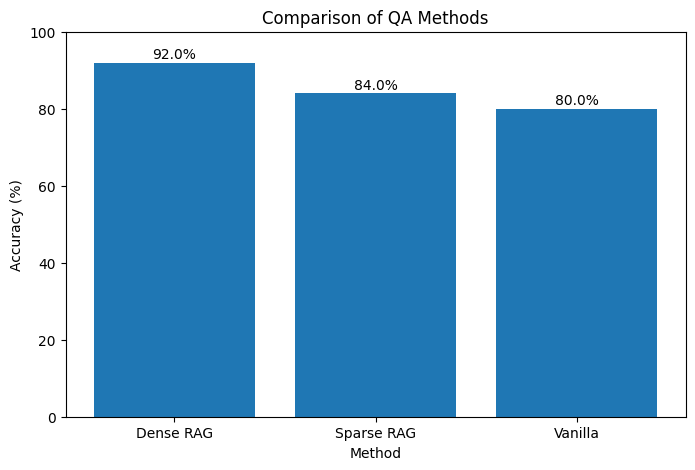

In [29]:
import matplotlib.pyplot as plt

accuracy_df = (
    all_results_df
    .groupby("method")["is_correct"]
    .mean()
    .reset_index()
)

accuracy_df["accuracy_percent"] = accuracy_df["is_correct"] * 100

print("Final Accuracy:")
display(accuracy_df)

plt.figure(figsize=(8, 5))
plt.bar(
    accuracy_df["method"],
    accuracy_df["accuracy_percent"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Method")
plt.title("Comparison of QA Methods")
plt.ylim(0, 100)

for i, acc in enumerate(accuracy_df["accuracy_percent"]):
    plt.text(
        i,
        acc + 1,
        f"{acc:.1f}%",
        ha="center"
    )

plt.show()

In [34]:
compare_df = (
    vanilla_results_df[
        ["id", "gold_answer", "predicted_answer", "is_correct"]
    ]
    .rename(columns={
        "predicted_answer": "vanilla_pred",
        "is_correct": "vanilla_correct"
    })
    .merge(
        sparse_results_df[
            ["id", "predicted_answer", "is_correct"]
        ].rename(columns={
            "predicted_answer": "sparse_pred",
            "is_correct": "sparse_correct"
        }),
        on="id"
    )
    .merge(
        dense_results_df[
            ["id", "predicted_answer", "is_correct"]
        ].rename(columns={
            "predicted_answer": "dense_pred",
            "is_correct": "dense_correct"
        }),
        on="id"
    )
)

In [49]:
desired_df = compare_df[
    (compare_df["vanilla_correct"] == True) &
    (
        (compare_df["sparse_correct"] == False) |
        (compare_df["dense_correct"] == False)
    )
]
desired_df

,id,gold_answer,vanilla_pred,vanilla_correct,sparse_pred,sparse_correct,dense_pred,dense_correct
4,benchmark_005,D,D,True,B,False,B,False
6,benchmark_007,C,C,True,C,True,B,False
28,benchmark_029,A,A,True,Using dense embeddings that can handle synonym...,False,A,True
32,benchmark_033,A,A,True,ERROR,False,A,True


In [54]:
for _, row in desired_df.iterrows():
    
    qid = row["id"]

    example = next(q for q in benchmark_questions if q["id"] == qid)

    question_text = format_mcq(example)

    print("\n" + "=" * 120)
    print(f"QUESTION ID: {qid}")
    print("=" * 120)

    print("\nQUESTION:")
    print(question_text)

    print("\nGOLD ANSWER:", example["answer"])

    print("\n" + "-" * 120)
    print("BM25 RETRIEVED CHUNKS")
    print("-" * 120)

    bm25_docs = bm25_retriever.invoke(question_text)

    for i, doc in enumerate(bm25_docs, 1):
        print(f"\n[BM25 Chunk {i}]")
        print(doc.page_content[:1000])  

    print("\nBM25 PREDICTION:", row["sparse_pred"])

    print("\n" + "-" * 120)
    print("FAISS RETRIEVED CHUNKS")
    print("-" * 120)

    faiss_docs = dense_retriever.invoke(question_text)

    for i, doc in enumerate(faiss_docs, 1):
        print(f"\n[FAISS Chunk {i}]")
        print(doc.page_content[:1000])  

    print("\nFAISS PREDICTION:", row["dense_pred"])

    print("\n" + "=" * 120)


QUESTION ID: benchmark_005

QUESTION:
Question:
Which special token's final-layer vector is used for BERT's next sentence prediction classifier?

Choices:
A. [SEP]
B. [MASK]
C. The final token of the second sentence
D. [CLS]

GOLD ANSWER: D

------------------------------------------------------------------------------------------------------------------------
BM25 RETRIEVED CHUNKS
------------------------------------------------------------------------------------------------------------------------

[BM25 Chunk 1]
10.2 • T RAINING BIDIRECTIONAL ENCODERS 7
X is actually formed by summing 3 embeddings: word, position, and ﬁrst/second
segment embeddings.
During training, the output vector hL
CLS from the ﬁnal layer associated with the
[CLS] token represents the next sentence prediction. As with the MLM objective,
we add a special head, in this case an NSP head, which consists of a learned set of
classiﬁcation weights WNSP∈ Rd×2 that produces a two-class prediction from the
raw [CLS] ve

## Note: I used ChatGPT and DeepSeek to help me complete the tasks. Before starting this assignment, I was not familiar with the pipeline of RAG-based systems. The final code was developed based on my own ideas, with additional help and guidance from these tools.